# DL055 小型语言模型训练与规模

完整Run All重新训练固定12配置，每run80步、8960有效token；总107520。约一分钟但取决于本机性能，不自动扩大预算。CPU、无下载、无付费API。先读lab.pdf再运行。

In [1]:
from pathlib import Path
import sys,json,math,unittest
candidates=[Path.cwd(),Path.cwd()/"units"/"055"]
ROOT=next((p.resolve() for p in candidates if p.name=="055" and (p/"experiment.py").exists()),None)
if ROOT is None: raise RuntimeError("从055或课程根启动Notebook")
sys.path.insert(0,str(ROOT))
from experiment import *
setup(5501);REPLAY=ROOT/"notebook_replay"
print("CPU float32",torch.__version__,"单线程")
print(json.dumps(protocol(),ensure_ascii=False,indent=2))

CPU float32 2.7.1+cpu 单线程
{
  "version": "1",
  "device": "cpu",
  "dtype": "float32",
  "threads": 1,
  "steps": 80,
  "batch_size": 16,
  "sequence_length": 7,
  "heads": 4,
  "layers": 2,
  "ffn_multiplier": 2,
  "dropout": 0,
  "lr": 0.003,
  "weight_decay": 0.01,
  "adam_betas": [
    0.9,
    0.999
  ],
  "grad_clip": 1.0,
  "warmup_timing_steps": 5,
  "checkpoints": [
    0,
    20,
    40,
    60,
    74,
    80
  ],
  "effective_token_limit_per_run": 8960,
  "aggregate_effective_token_limit": 107520,
  "training_timeout_seconds_per_worker": 180,
  "declared_scope": "2 widths x2 distinct training pools x3 initializations; no scaling-law fit",
  "test_policy": "test split retained but not scored or used for tuning",
  "configs": [
    {
      "d": 16,
      "pool": 32,
      "seed": 5501,
      "name": "d16_n32_s5501"
    },
    {
      "d": 16,
      "pool": 32,
      "seed": 5502,
      "name": "d16_n32_s5502"
    },
    {
      "d": 16,
      "pool": 32,
      "seed": 5503,
 

## 1 手算参数 token与计算预算
参数不是激活；累计有效token包括重复；FLOPs是主要矩阵乘加模型，不是实测时间。

In [2]:
for d in [16,32]:
    model=TinyLM(d)
    print("D",d,"公式参数",parameter_formula(d),"实际参数",sum(p.numel() for p in model.parameters()))
    print("前向矩阵FLOPs",forward_matmul_flops(d),"80步训练估算",3*80*forward_matmul_flops(d))
print("每步",BATCH*L,"每run",80*BATCH*L,"全部12run",12*80*BATCH*L)
print("参数公式不是进程RSS")

D 16 公式参数 5252 实际参数 5252
前向矩阵FLOPs 1089536 80步训练估算 261488640
D 32 公式参数 18676 实际参数 18676
前向矩阵FLOPs 4014080 80步训练估算 963379200
每步 112 每run 8960 全部12run 107520
参数公式不是进程RSS


## 2 独立测试
覆盖标签、规则、参数、FLOPs、因果性、前缀长度、真实两步AdamW及全部随包权重读取。测试另外执行8步小训练，不改变正式结果。

In [3]:
from test_experiment import Tests
outcome=unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(Tests))
if not outcome.wasSuccessful():raise RuntimeError("DL055 tests failed")

test_causal_and_length (test_experiment.Tests.test_causal_and_length) ... 

ok


test_data_and_shift (test_experiment.Tests.test_data_and_shift) ... 

ok


test_packaged_checkpoints (test_experiment.Tests.test_packaged_checkpoints) ... 

...

test_training_checkpoint_and_adam (test_experiment.Tests.test_training_checkpoint_and_adam) ... 

ok


test_uniform_loss (test_experiment.Tests.test_uniform_loss) ... 

ok


----------------------------------------------------------------------
Ran 6 tests in 1.384s

OK


## 3 真正重新训练
每配置在独立Python进程运行，以取得该worker的峰值RSS。协议先写入再训练；测试划分不评分。运行期间不会扩大宽度、步数或种子范围。

In [4]:
results=run(REPLAY)
print("累计有效训练token",results["total_effective_training_tokens"])
print(json.loads((REPLAY/"runtime.json").read_text()))

d16_n32_s5501 validation 1.173791


d16_n32_s5502 validation 1.185691


d16_n32_s5503 validation 1.173513


d16_n128_s5501 validation 1.124627


d16_n128_s5502 validation 1.141072


...

d32_n32_s5503 validation 1.387267


d32_n128_s5501 validation 1.06075


d32_n128_s5502 validation 1.059999


d32_n128_s5503 validation 1.054648


累计有效训练token 107520
{'python': '3.12.14', 'torch': '2.7.1+cpu', 'numpy': '2.3.5', 'platform': 'Linux-6.18.44-x86_64-with-glibc2.41', 'device': 'CPU', 'dtype': 'float32', 'threads': 1, 'fresh_worker_per_configuration': True, 'wall_seconds': 42.07197819400062, 'cpu_model': 'INTEL(R) XEON(R) PLATINUM 8573C'}


## 4 实际优化链与重放核对
同环境固定种子比较验证NLL；计时与RSS允许变化，不要求字节复现。读取一条真实偏置的两步记录，按讲义复算裁剪和AdamW。

In [5]:
from statistics import mean,stdev
original=json.loads((ROOT/"outputs/results.json").read_text())
for old,new in zip(original["runs"],results["runs"]):
    delta=abs(old["final_validation"]["nll"]-new["final_validation"]["nll"])
    print(new["config"]["name"],"验证NLL",new["final_validation"]["nll"],"与随包差",delta)
    if delta>1e-5: raise RuntimeError("numeric replay differs; inspect version and hardware")
real=json.loads((REPLAY/"runs/d16_n128_s5501/results.json").read_text())
for step in real["steps"][:2]:print(step["step"],step["optimizer_example"])
for d in [16,32]:
    for pool in [32,128]:
        values=[r["final_validation"]["nll"] for r in results["runs"] if r["config"]["d"]==d and r["config"]["pool"]==pool]
        print(d,pool,"mean",mean(values),"sample SD",stdev(values))

d16_n32_s5501 验证NLL 1.1737908124923706 与随包差 0.0
d16_n32_s5502 验证NLL 1.1856905221939087 与随包差 0.0
d16_n32_s5503 验证NLL 1.173512578010559 与随包差 0.0
d16_n128_s5501 验证NLL 1.1246274709701538 与随包差 0.0
d16_n128_s5502 验证NLL 1.141072154045105 与随包差 0.0
d16_n128_s5503 验证NLL 1.1324410438537598 与随包差 0.0
d32_n32_s5501 验证NLL 1.4556419849395752 与随包差 0.0
d32_n32_s5502 验证NLL 1.493101954460144 与随包差 0.0
d32_n32_s5503 验证NLL 1.387266755104065 与随包差 0.0
d32_n128_s5501 验证NLL 1.0607497692108154 与随包差 0.0
d32_n128_s5502 验证NLL 1.0599987506866455 与随包差 0.0
d32_n128_s5503 验证NLL 1.0546478033065796 与随包差 0.0
1 {'parameter': 'head.bias[3]', 'before': -0.1027657687664032, 'raw_gradient': -0.040450431406497955, 'analytic_ce_gradient': -0.040450435131788254, 'clipped_gradient': -0.03665156289935112, 'after': -0.0997626855969429, 'm': -0.003665156429633498, 'v': 1.3433370895654662e-06}
2 {'parameter': 'head.bias[3]', 'before': -0.0997626855969429, 'raw_gradient': -0.02791573852300644, 'analytic_ce_gradient': -0.0279157310724258

## 5 从本次全部结果重新画图
7张图均内嵌真实PNG。吞吐与RSS来自本次测量，可能与PDF的原始执行记录不同；科学数值对齐不要求机器负载相同。

Rendered 7 figures
01_training_flow.png


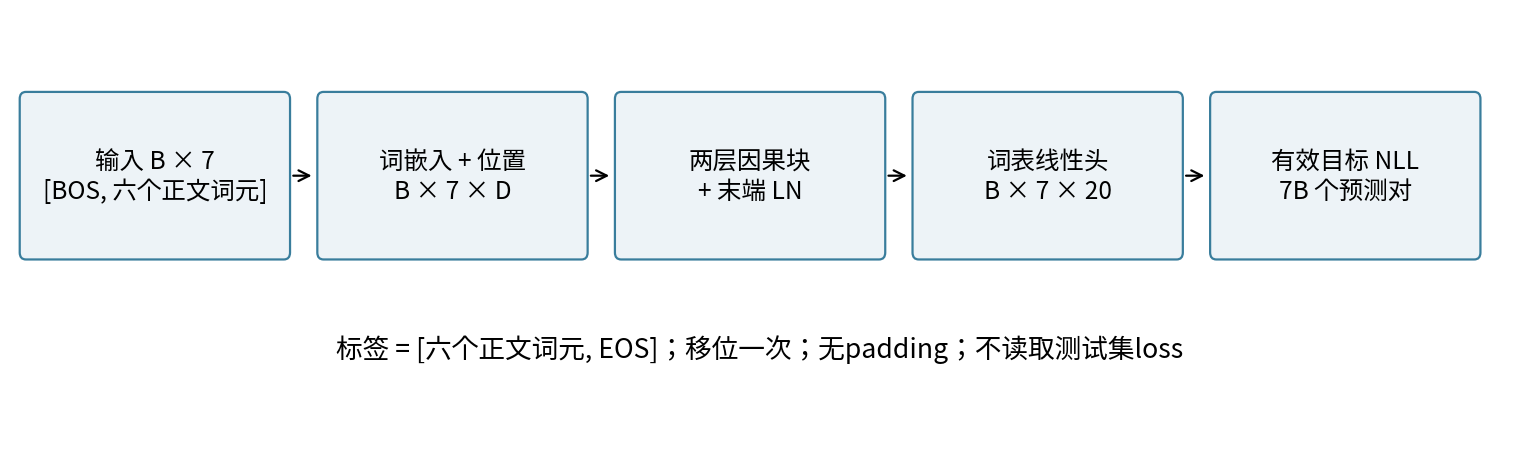

02_counts.png


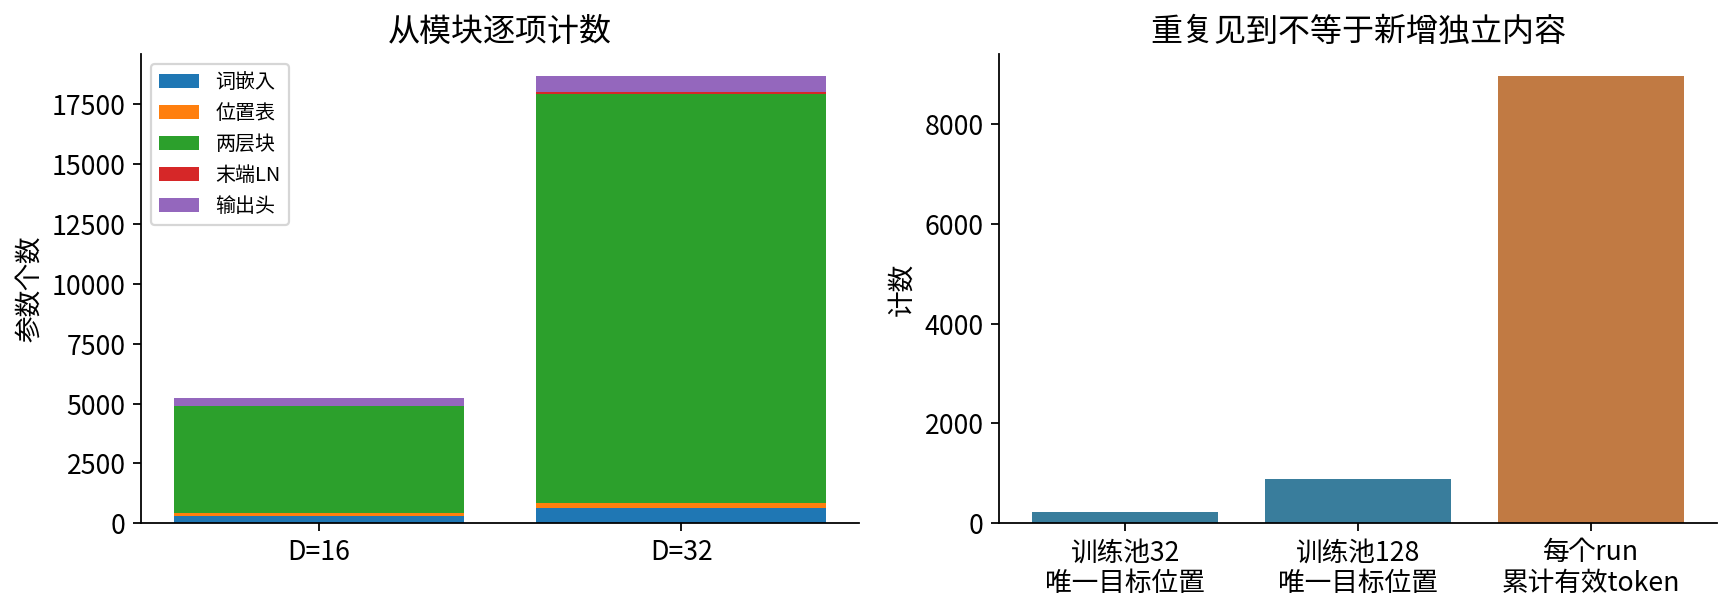

03_learning.png


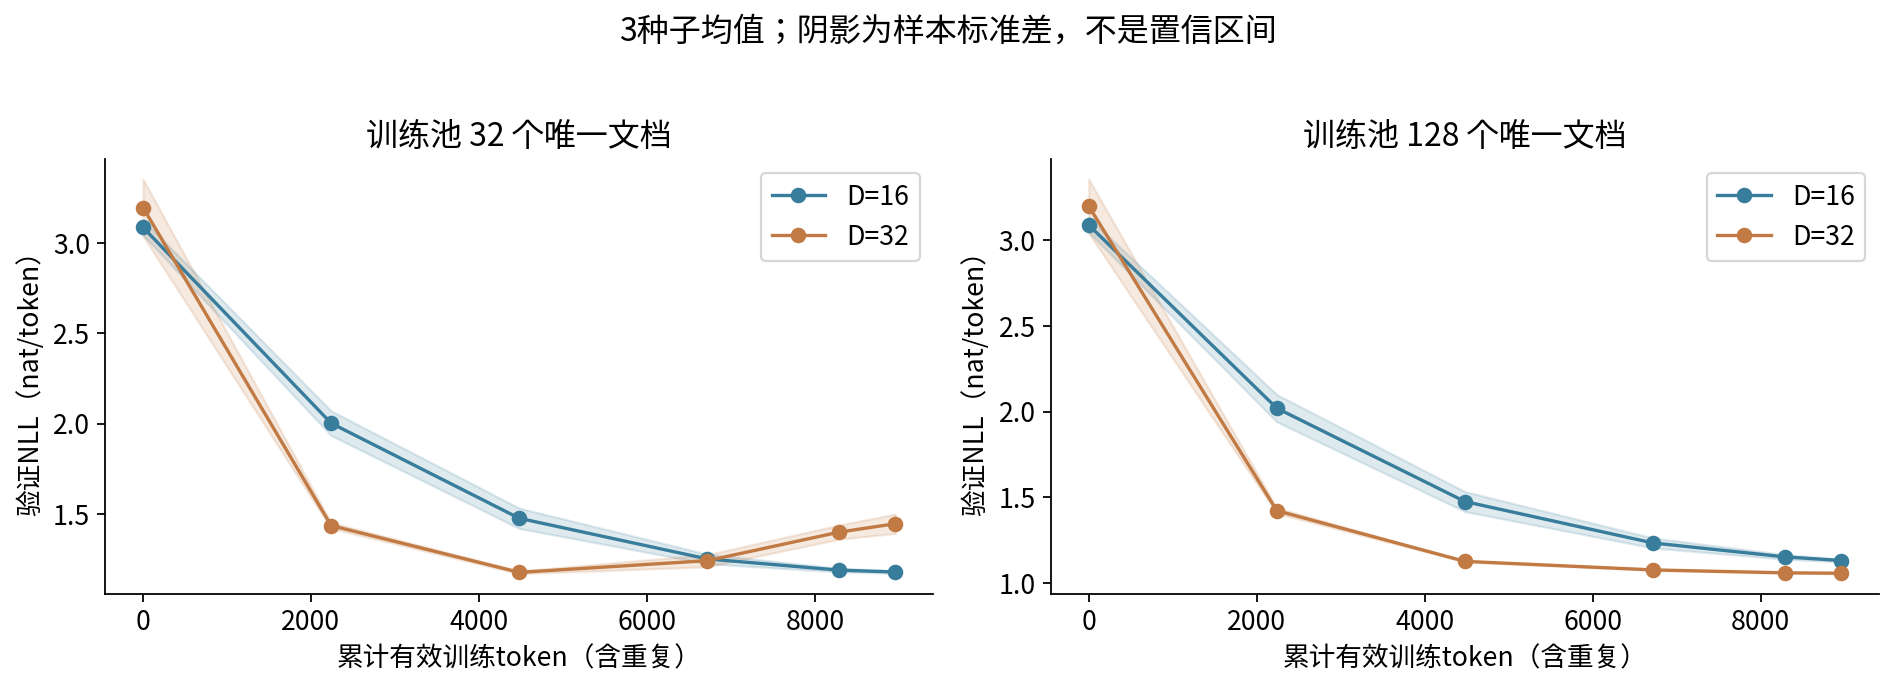

04_gap.png


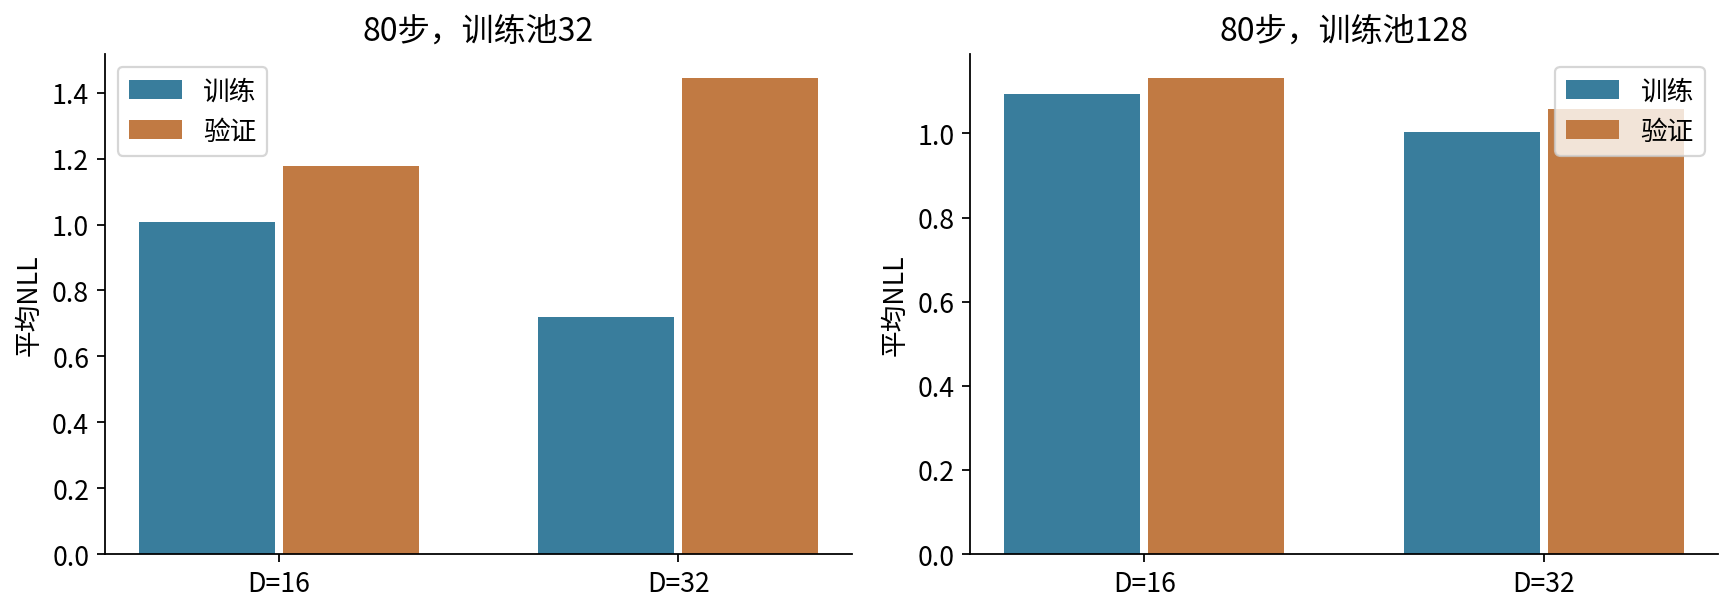

05_compute.png


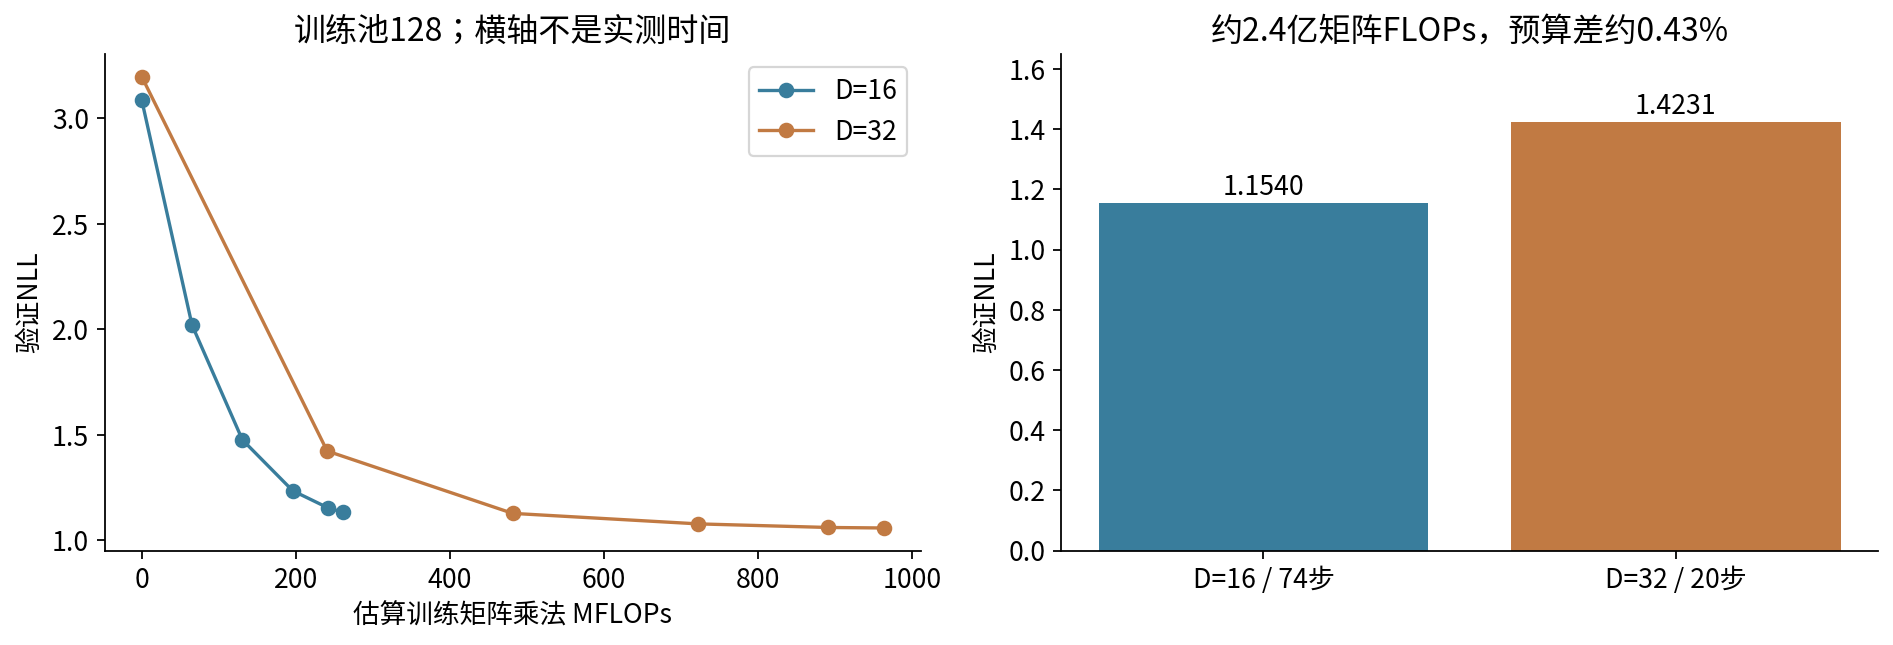

06_positions.png


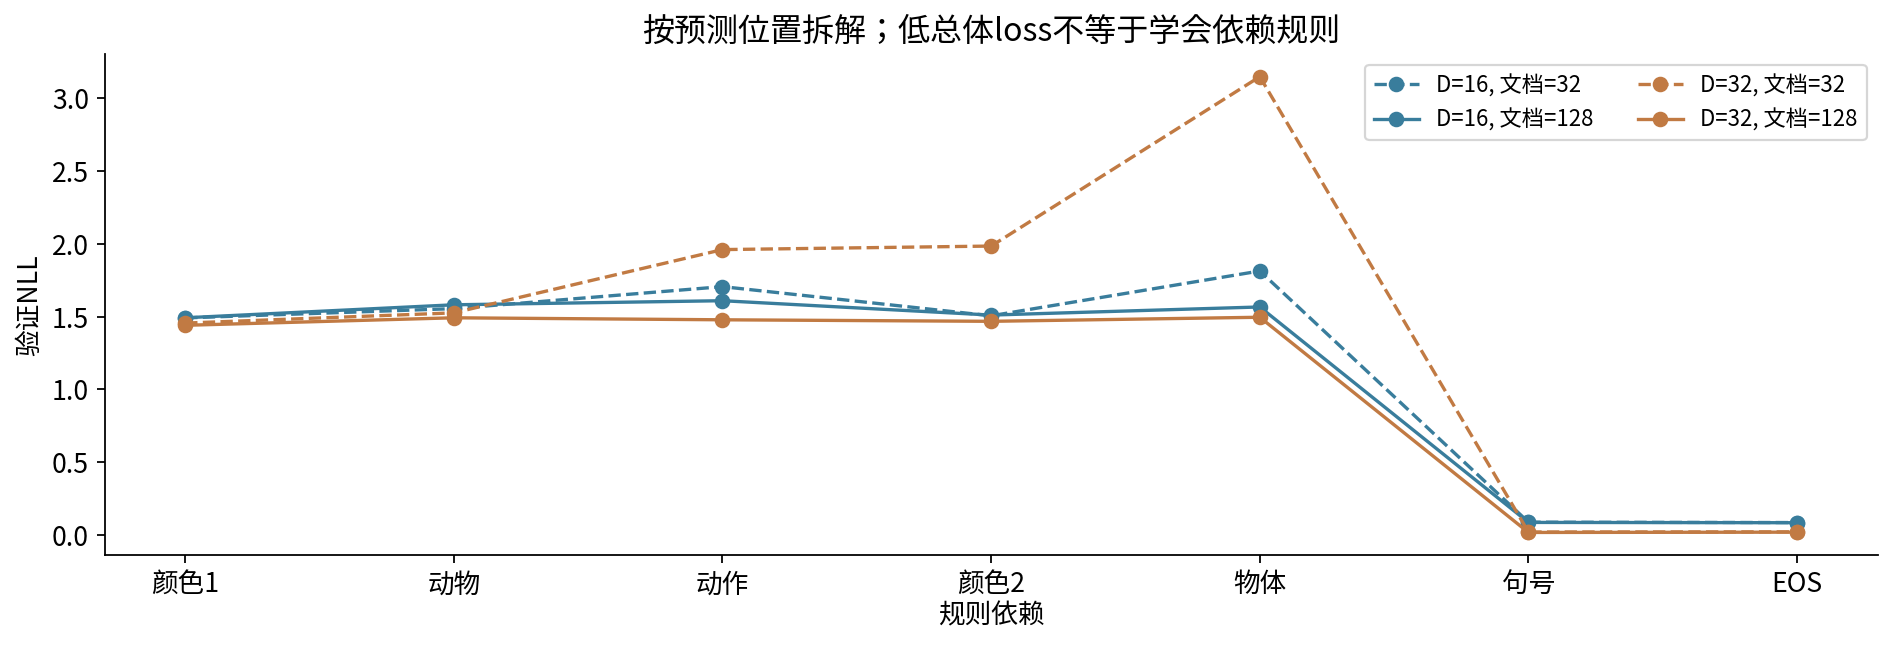

07_measurement.png


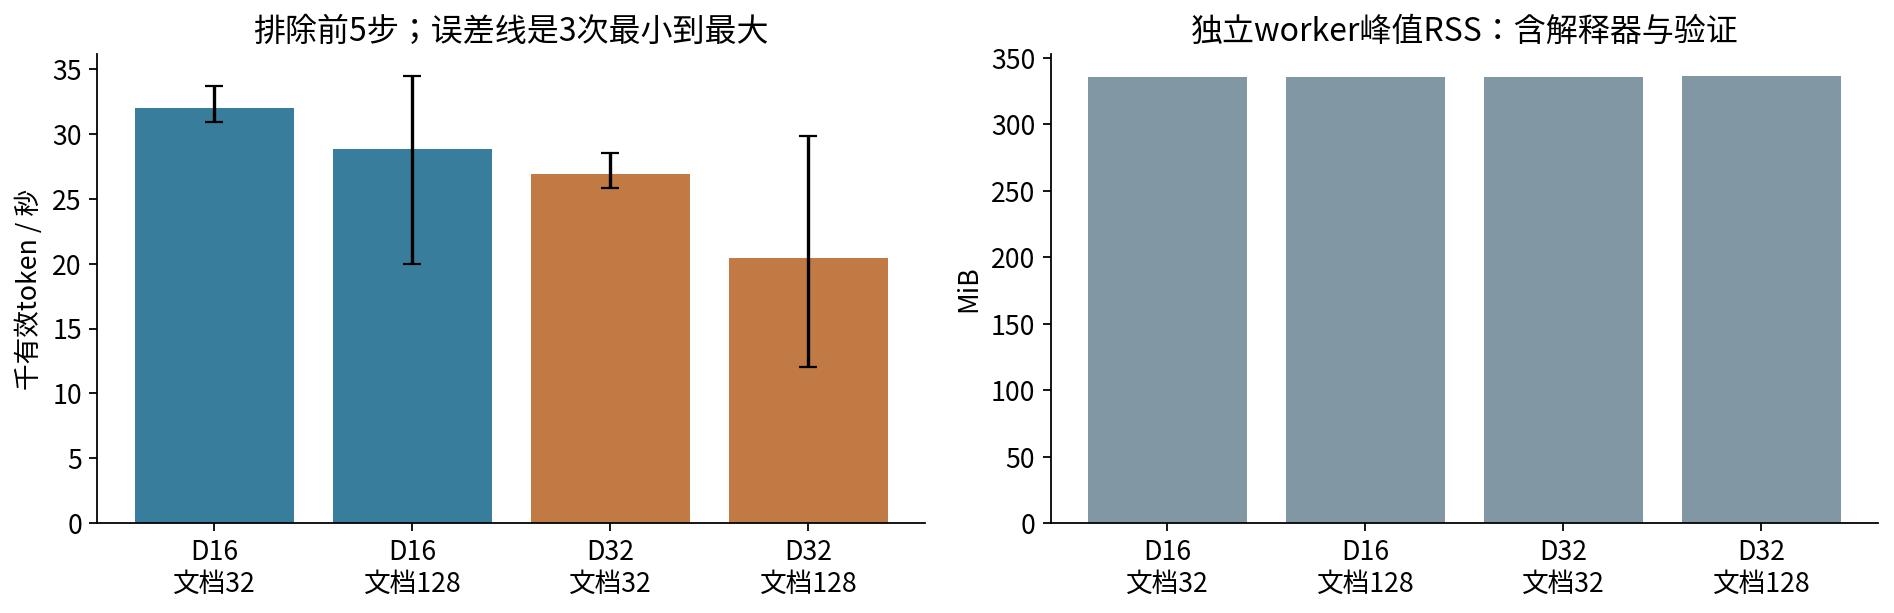

In [6]:
from make_figures import main as draw
from IPython.display import display,Image
folder=draw(REPLAY/"results.json",REPLAY/"figures")
for path in sorted(folder.glob("*.png")):
    print(path.name);display(Image(filename=str(path)))

## 6 写出受证据限制的结论
比较固定token与约2.4亿矩阵FLOPs两个口径；保留32文档大模型的验证退化；检查颜色2规则位置；说明GPU未测、数据为合成、仅3初始化、未拟合幂律。不能由本课外推前沿模型或中文能力。